# Bitcoin Persistence-Enhanced Log-Return Transformer

## Role
This notebook evaluates the project's final supervised Transformer-style Bitcoin model, using the same persistence-enhancement philosophy as the PE-LSTM in Notebook 03.

## Inputs
The canonical Bitcoin daily Close series (same pipeline as Notebooks 01-03); a log-return representation; train-only scaling; and the frozen PE-Transformer forecast artifact `results/persistence_enhanced_transformer_forecast.csv` (verified present: one `Persistence_Enhanced_Transformer` column, 1,061 rows).

## Outputs
Artifact-derived PE-Transformer metrics, figures, comparative context against Naive/ARIMA/PE-LSTM, and a reproducibility record. This notebook does not create or overwrite any authoritative forecast vector.

## Depends On
`01_Bitcoin_Data_EDA.ipynb`
`02_Bitcoin_Classical_Baselines.ipynb`
`03_Bitcoin_PE_LSTM.ipynb`

## Authoritative Status
`AUTHORITATIVE MODEL ANALYSIS` (the repository's own terminology for this notebook; the PE-Transformer forecast itself is catalogued as "Supporting authoritative evidence" in `results/authoritative_artifact_hashes.md`, distinct from the primary comparison vector).

## What This Notebook Does Not Do
It does not evaluate Chronos, TimesFM, or any foundation model, and it does not calculate final Trust Scores, run cross-domain synthesis, or perform final statistical inference. Those are handled in later notebooks.

# 1. Objective and Research Question

> Does a Transformer-style sequence model, trained on Bitcoin log returns and reconstructed around the most recently observed price, improve on the PE-LSTM from Notebook 03 or on the strong classical forecasting floor established in Notebook 02?

This question matters because the model increases architectural complexity and uses attention-based sequence modelling. The research question is not whether a Transformer is theoretically more advanced — it is whether the added complexity produces a measurable forecasting benefit under the same frozen Bitcoin test protocol used for every other model in this project. The Transformer is not assumed to outperform the LSTM.

# 2. Setup

Standard project-root discovery and the repository's existing Bitcoin pipeline utilities. No data-loading or metric logic is duplicated here. This notebook loads the frozen forecast artifact; it does not import TensorFlow or any neural-network library during normal execution.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.bitcoin_pipeline import *

RUN_GENERATION = False
PROMOTE_TO_AUTHORITATIVE = False
RUN_TRAINING = False  # Safety flag: this notebook is artifact-driven and does not retrain the PE-Transformer.

# 3. Data and Method

In [2]:
# Load once: canonical target/split and the frozen validated forecast vectors.
_, target = load_bitcoin_target(ROOT)
train, test = canonical_split(target)
validated = load_validated_forecasts(ROOT)
forecasts = forecast_series(validated, target)
validated[['Actual', 'Persistence_Enhanced_Transformer']].tail()

,Actual,Persistence_Enhanced_Transformer
Timestamp,,
2026-07-03 00:00:00+00:00,62522.46,60115.583894
2026-07-04 00:00:00+00:00,63086.18,61136.582567
2026-07-05 00:00:00+00:00,63587.06,61687.472448
2026-07-06 00:00:00+00:00,64000.10,62176.114013
2026-07-07 00:00:00+00:00,63902.77,62580.256015


## 3.1 Target Representation

`r_t = log(P_t / P_(t-1))`

The PE-Transformer is trained on the same daily log-return series as the PE-LSTM. Target formulation: **IDENTICAL TO PE-LSTM** (verified from `src/bitcoin_transformer_models.py`: both use `np.log(target / target.shift(1))` and the same persistence-anchored reconstruction in Section 3.3). This identical target formulation improves comparability between the two neural models — the comparison below is not confounded by different target definitions, only by the input-window length (Section 3.2).

**Scaling** (verified from `src/bitcoin_transformer_models.py`, `generate_pe_transformer_forecast`): a `MinMaxScaler(feature_range=(-1, 1))` is fit **only** on training-period log returns (`train_returns`), then applied (`.transform`, never re-fit) to the test-adjacent context used to build test-period input sequences. No validation or test observation ever enters scaler fitting.

## 3.2 Architecture

Every field below is read directly from `src/bitcoin_transformer_models.py` (`build_transformer` and `generate_pe_transformer_forecast`); nothing is guessed.

In [3]:
architecture_table = pd.DataFrame({
    'Value': [
        '128 daily log returns',
        '1 (univariate log return)',
        64,
        '1 (single self-attention + feed-forward block)',
        4,
        128,
        'None (use_positional_embedding=False) -- the authoritative model uses the simpler non-positional encoder; see Development Provenance, Section 7',
        0.1,
        'Post-norm LayerNormalization (epsilon=1e-6), applied after the residual sum following attention and again after the residual sum following the feed-forward block',
        'Dense(32, relu) then Dense(1, linear)',
        'Mean squared error (mse)',
        'Adam',
        'Not explicitly configured / framework default (Keras Adam default learning rate)',
        32,
        20,
        "Yes: EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)",
        42,
    ],
}, index=[
    'Input window', 'Input features', 'Model dimension (d_model)', 'Number of Transformer blocks/layers',
    'Attention heads', 'Feed-forward dimension', 'Positional encoding', 'Dropout', 'Normalisation',
    'Output layer', 'Loss function', 'Optimizer', 'Learning rate', 'Batch size', 'Maximum epochs',
    'Early stopping', 'Random seed',
])
architecture_table

,Value
Input window,128 daily log returns
Input features,1 (univariate log return)
Model dimension (d_model),64
Number of Transformer blocks/layers,1 (single self-attention + feed-forward block)
Attention heads,4
Feed-forward dimension,128
Positional encoding,None (use_positional_embedding=False) -- the a...
Dropout,0.1
Normalisation,"Post-norm LayerNormalization (epsilon=1e-6), a..."
Output layer,"Dense(32, relu) then Dense(1, linear)"


> The neural-model comparison is not fully controlled for context length: the PE-LSTM uses a 30-return lookback, while the PE-Transformer uses 128 returns.

This is visible here and is repeated in Limitations (Section 9).

## 3.3 Persistence-Enhancement Design

`P_hat_t = P_(t-1) * exp(r_hat_t)`

This matches Notebook 03's PE-LSTM reconstruction exactly (verified from `src/bitcoin_transformer_models.py`: the reconstruction uses `target.shift(1)` reindexed to the test dates, then multiplies by `exp` of the predicted return). The network predicts the movement/return rather than the raw price level; the forecast is anchored to the latest observed actual price, `P_(t-1)`, which is strictly prior information already available at the forecast origin for date `t` — no target leakage occurs. The PE-Transformer and PE-LSTM share the same persistence-enhancement design.

## 3.4 Training and Validation Protocol

In [4]:
training_protocol = pd.DataFrame({
    'Detail': [
        f"{train.index.min().date()} to {train.index.max().date()} ({len(train)} days)",
        'validation_split=0.1 inside model.fit, applied to training sequences only (shuffle=False, so this is the chronologically most-recent 10% of the training set, never test data)',
        f"{test.index.min().date()} to {test.index.max().date()} ({len(test)} days)",
        '128 days of prior log returns',
        'Fit only on training-period log returns; applied (never re-fit) to the test-adjacent context',
        42,
        'Yes: single-threaded op determinism (intra/inter-op parallelism pinned to 1, TensorFlow op determinism enabled) plus seeded layer initializers throughout the model',
        False,
        32,
        20,
        "Yes: EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)",
        'restore_best_weights=True (best validation-loss epoch restored, not necessarily the final epoch)',
        'Yes -- the final test period is never used for scaler fitting, hyperparameter selection, early stopping, or training',
    ],
}, index=[
    'Training period', 'Validation split', 'Final test period', 'Lookback length',
    'Scaler fitting boundary', 'Seed', 'Deterministic framework controls', 'Shuffle setting',
    'Batch size', 'Epochs', 'Early stopping', 'Checkpoint/model-selection logic', 'Final-test isolation',
])
training_protocol

,Detail
Training period,2012-01-01 to 2023-08-11 (4241 days)
Validation split,"validation_split=0.1 inside model.fit, applied..."
Final test period,2023-08-12 to 2026-07-07 (1061 days)
Lookback length,128 days of prior log returns
Scaler fitting boundary,Fit only on training-period log returns; appli...
Seed,42
Deterministic framework controls,Yes: single-threaded op determinism (intra/int...
Shuffle setting,False
Batch size,32
Epochs,20


## 3.5 Training Diagnostics

`src/bitcoin_transformer_models.py` captures a training-history object from `model.fit(...)` (via `history.history`) and its CLI (`main()`) supports an optional `--history-output` flag to save it as JSON. This repository was checked read-only for any such saved file: none exists under `results/` or anywhere else tracked by Git for the authoritative PE-Transformer run, so the flag was evidently not used when the frozen artifact was generated.

In [5]:
training_diagnostics = pd.DataFrame({
    'Status': ['No', 'No', 'Yes', 'Yes', 'No'],
}, index=[
    'Epoch-level training loss preserved',
    'Epoch-level validation loss preserved',
    'Final forecast vector preserved',
    'Final model configuration preserved',
    'Independent rerun vectors preserved',
])
training_diagnostics

,Status
Epoch-level training loss preserved,No
Epoch-level validation loss preserved,No
Final forecast vector preserved,Yes
Final model configuration preserved,Yes
Independent rerun vectors preserved,No


> Epoch-level training-history evidence was not preserved as an authoritative artifact, so no retrospective training-loss curve is fabricated.

# 4. PE-Transformer Results

## 4.1 Forecast Performance

In [6]:
pe_transformer_metrics = metric_table(
    validated.Actual,
    {'Persistence-Enhanced Log-Return Transformer': validated.Persistence_Enhanced_Transformer},
    train,
)
pe_transformer_metrics.round(3)

,MAE,RMSE,MAPE,sMAPE,MASE,N
Model,,,,,,
Persistence-Enhanced Log-Return Transformer,2019.366,2559.75,2.711,2.759,7.161,1061


Recomputed here from the frozen `results/persistence_enhanced_transformer_forecast.csv` vector via the repository's canonical `metric_table` function, not hard-coded.

## 4.2 Context Against Persistence

Intentionally small: only Naive is used for context here (the full multi-model context is Section 6).

In [7]:
context_names = ['Naive', 'Persistence-Enhanced Log-Return Transformer']
context_table = metric_table(validated.Actual, {n: forecasts[n] for n in context_names}, train)
context_table['% difference vs Naive MAE'] = 100 * (context_table['MAE'] / context_table.loc['Naive', 'MAE'] - 1)
context_table[['MAE', 'RMSE', 'Relative MAE vs Naive', '% difference vs Naive MAE']].round(3)

,MAE,RMSE,Relative MAE vs Naive,% difference vs Naive MAE
Model,,,,
Naive,1290.353,1853.625,1.000,0.000
Persistence-Enhanced Log-Return Transformer,2019.366,2559.750,1.565,56.497


The PE-Transformer's MAE is approximately 56.5% higher than Naive's (exact value in the table above) -- a materially larger gap than the PE-LSTM's approximately 2.4% (Notebook 03). No statistical-significance claim is made here; that determination belongs to `11_Bitcoin_Statistical_Inference.ipynb`.

## 4.3 Forecast vs Actual

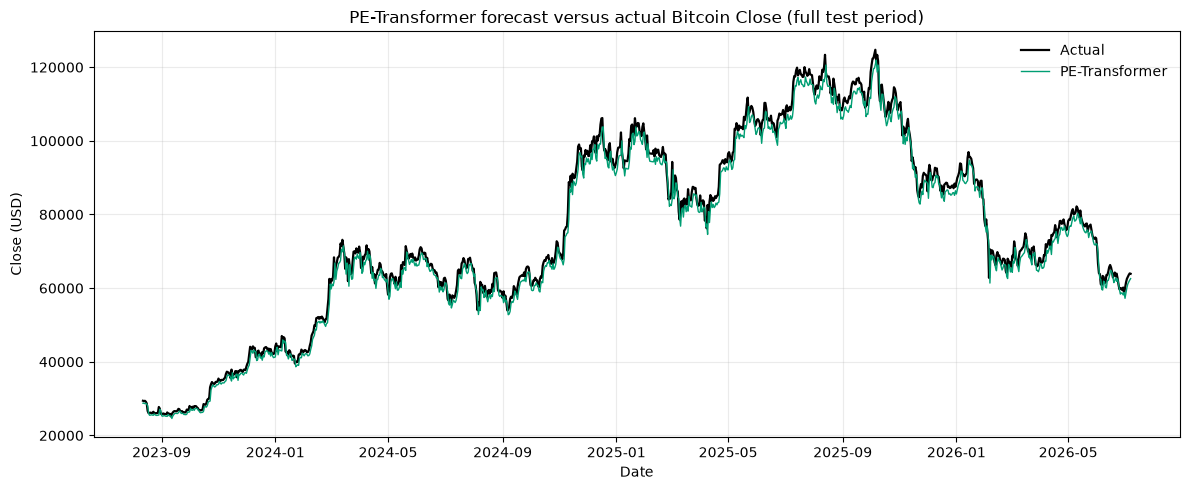

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(validated.index, validated.Actual, color='black', linewidth=1.6, label='Actual')
ax.plot(validated.index, validated.Persistence_Enhanced_Transformer, color='#009E73', linewidth=1.0, label='PE-Transformer')
ax.set(title='PE-Transformer forecast versus actual Bitcoin Close (full test period)', xlabel='Date', ylabel='Close (USD)')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 4.4 Residual Analysis

Residuals are defined consistently as `e_t = y_t - y_hat_t` (Actual minus Forecast).

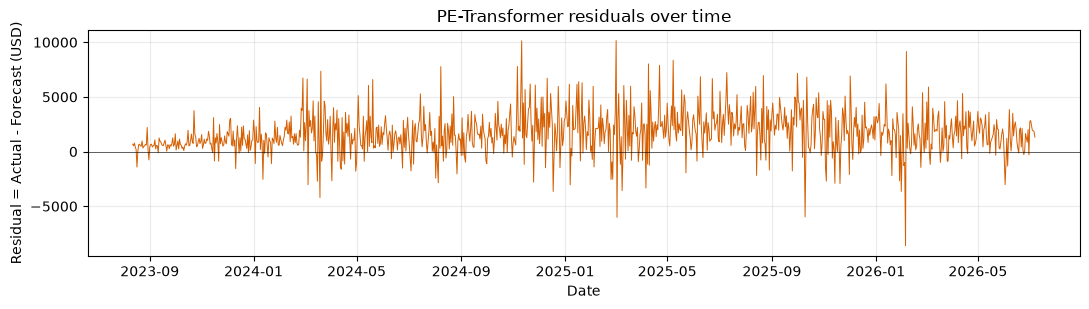

In [9]:
residual = validated.Actual - validated.Persistence_Enhanced_Transformer

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(residual.index, residual, color='#D55E00', linewidth=0.7)
ax.axhline(0, color='black', linewidth=0.7, alpha=0.6)
ax.set(title='PE-Transformer residuals over time', xlabel='Date', ylabel='Residual = Actual - Forecast (USD)')
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

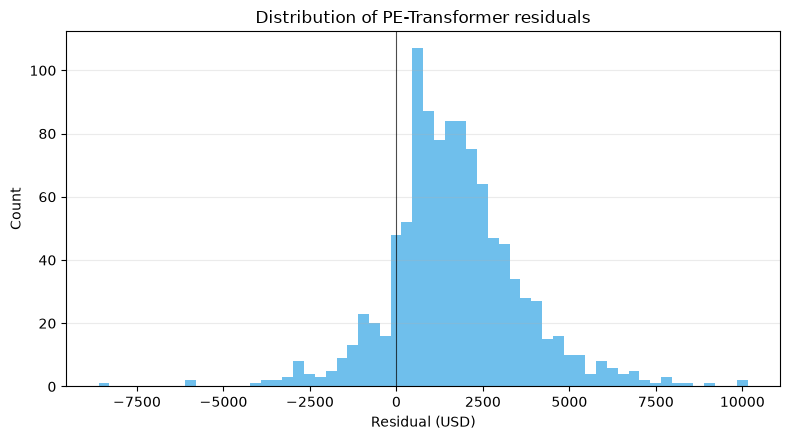

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(residual, bins=60, color='#56B4E9', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8, alpha=0.7)
ax.set(title='Distribution of PE-Transformer residuals', xlabel='Residual (USD)', ylabel='Count')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

In [11]:
residual_summary = pd.Series({
    'Mean': residual.mean(), 'Median': residual.median(), 'Std Dev': residual.std(),
    'Min': residual.min(), 'Max': residual.max(),
}, name='Persistence-Enhanced Log-Return Transformer').to_frame().T.round(3)
residual_summary

,Mean,Median,Std Dev,Min,Max
Persistence-Enhanced Log-Return Transformer,1706.123,1562.054,1909.162,-8608.167,10150.614


The residual mean is strongly positive (approximately +\$1,706, median approximately +\$1,562) against a dispersion of approximately \$1,909 -- a pronounced systematic bias: the model consistently under-forecasts, predicting a lower price than the actual outcome far more often and by a much larger margin than either Naive or the PE-LSTM (Notebook 03) do. The largest absolute residuals occur in isolated dates across the test window rather than clustering in one segment, and residual dispersion does not show an obvious trend over time. This is a visual/numerical characterisation only; residuals are not formally tested for whiteness here.

# 5. Comparative Context

This section places the PE-Transformer's own evidence (Section 4) in context against Naive, ARIMA, and the PE-LSTM.

## 5.1 Four-Model Comparison

In [12]:
names = [
    'Naive',
    'ARIMA Rolling One-Step',
    'Persistence-Enhanced Log-Return LSTM',
    'Persistence-Enhanced Log-Return Transformer',
]
four_model_comparison = metric_table(validated.Actual, {name: forecasts[name] for name in names}, train)
four_model_comparison.sort_values('RMSE').round(3)

,MAE,RMSE,MAPE,sMAPE,MASE,N,Relative MAE vs Naive
Model,,,,,,,
Naive,1290.353,1853.625,1.743,1.744,4.576,1061,1.000
ARIMA Rolling One-Step,1299.875,1866.303,1.754,1.754,4.609,1061,1.007
Persistence-Enhanced Log-Return LSTM,1321.365,1881.091,1.784,1.792,4.686,1061,1.024
Persistence-Enhanced Log-Return Transformer,2019.366,2559.750,2.711,2.759,7.161,1061,1.565


## 5.2 RMSE Comparison

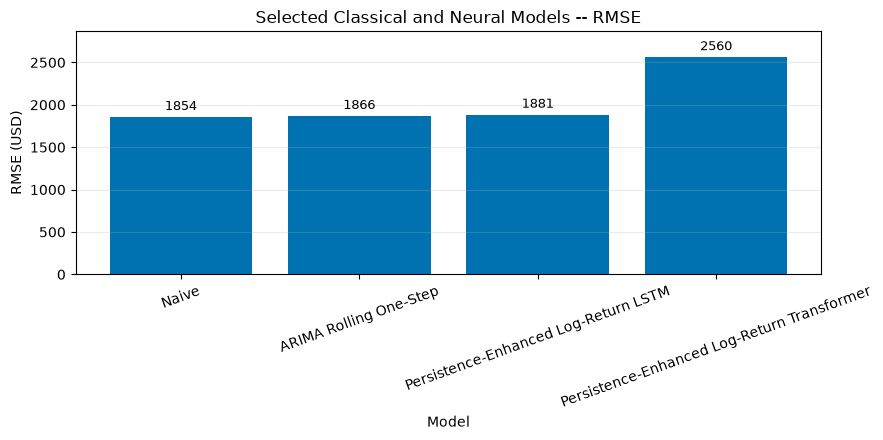

In [13]:
ranked = four_model_comparison['RMSE'].sort_values()
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(ranked.index, ranked.values, color='#0072B2')
ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=9)
ax.set(title='Selected Classical and Neural Models -- RMSE', xlabel='Model', ylabel='RMSE (USD)')
ax.set_ylim(0, ranked.max() * 1.12)
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

This is a four-model subset, not the full Bitcoin ranking -- Notebook 02 covers all five classical benchmarks, and the complete ten-model roster is compared elsewhere in this project (e.g. `18_Cross_Domain_Comparison.ipynb`).

## 5.3 PE-LSTM vs PE-Transformer Architecture Comparison

In [14]:
architecture_comparison = pd.DataFrame({
    'PE-LSTM (Notebook 03)': [
        'Log return', 'Yes', 30, 'Recurrent', 1, 32, 'N/A',
        'Not preserved / not reported', 20, 32,
        'Seed 42, single-thread op determinism, seeded initializers',
        f"{four_model_comparison.loc['Persistence-Enhanced Log-Return LSTM', 'MAE']:.3f}",
        f"{four_model_comparison.loc['Persistence-Enhanced Log-Return LSTM', 'RMSE']:.3f}",
    ],
    'PE-Transformer (this notebook)': [
        'Log return', 'Yes', 128, 'Self-attention', 1, 64, 4,
        'Not preserved / not reported', 20, 32,
        'Seed 42, single-thread op determinism, seeded initializers',
        f"{four_model_comparison.loc['Persistence-Enhanced Log-Return Transformer', 'MAE']:.3f}",
        f"{four_model_comparison.loc['Persistence-Enhanced Log-Return Transformer', 'RMSE']:.3f}",
    ],
}, index=[
    'Target', 'Persistence reconstruction', 'Input window', 'Core sequence mechanism',
    'Layers', 'Hidden/model dimension', 'Attention heads', 'Parameter count',
    'Training epochs', 'Batch size', 'Deterministic controls', 'Final MAE', 'Final RMSE',
])
architecture_comparison

,PE-LSTM (Notebook 03),PE-Transformer (this notebook)
Target,Log return,Log return
Persistence reconstruction,Yes,Yes
Input window,30,128
Core sequence mechanism,Recurrent,Self-attention
Layers,1,1
Hidden/model dimension,32,64
Attention heads,N/A,4
Parameter count,Not preserved / not reported,Not preserved / not reported
Training epochs,20,20
Batch size,32,32


Parameter counts are not preserved as artifacts for either model, and are not computed here by constructing either network (doing so would require importing TensorFlow, which this artifact-driven notebook deliberately avoids by default); both are reported as `Not preserved / not reported` rather than guessed.

> The PE-LSTM and PE-Transformer comparison is not a fully controlled architecture experiment because their input-window lengths differ.

# 6. Reproducibility Record

In [15]:
reproducibility_record = pd.DataFrame({
    'Evidence': [
        42,
        'TensorFlow / Keras',
        'Not verified in this notebook (recorded historically in docs/bitcoin_reproducibility.md as TensorFlow 2.21.0)',
        'CPU-only (recorded historically as Windows x86-64, Python 3.13.2)',
        'Yes',
        'Yes',
        'Yes -- three fresh-kernel reruns (repository Git history: commits documenting the audited positional-embedding regression)',
        '0 (bit-identical across those three historically verified runs, including identical loss histories)',
        'No',
        'Yes',
        'Yes',
        'Partial -- the generation script (src/bitcoin_transformer_models.py) is present and preserved, but full end-to-end regeneration was not re-executed or re-verified in this notebook',
    ],
}, index=[
    'Random seed', 'Framework', 'Framework version', 'Device',
    'Deterministic execution requested', 'Shuffle disabled', 'Fresh-kernel rerun performed',
    'Reported run-to-run difference', 'Independent rerun forecast vectors preserved',
    'Final frozen forecast preserved', 'Forecast hash protected', 'Full model regeneration currently reproducible',
])
reproducibility_record

,Evidence
Random seed,42
Framework,TensorFlow / Keras
Framework version,Not verified in this notebook (recorded histor...
Device,CPU-only (recorded historically as Windows x86...
Deterministic execution requested,Yes
Shuffle disabled,Yes
Fresh-kernel rerun performed,Yes -- three fresh-kernel reruns (repository G...
Reported run-to-run difference,0 (bit-identical across those three historical...
Independent rerun forecast vectors preserved,No
Final frozen forecast preserved,Yes


The three-fresh-kernel-run determinism check for the PE-Transformer is historically documented (matching in spirit the PE-LSTM's own three-run check in Notebook 03), but the individual run vectors were not preserved as separate files -- only the resulting single frozen vector remains. No fake rerun evidence or fabricated determinism figure is presented; "historically verified" is kept explicitly distinct from "independently reproducible from preserved run artifacts" (the latter is No).

# 7. Development Provenance

**HISTORICAL DEVELOPMENT EVIDENCE — NOT PART OF FINAL RANKING**

Several Transformer variants existed during development before the final persistence-enhanced, log-return formulation was adopted. Verified historical metrics survive in this repository's Git history and are reproduced read-only below (not rerun).

In [16]:
historical_provenance = pd.DataFrame([
    {'Variant': 'Transformer v1 (original)', 'Target Representation': 'Raw price', 'Status': 'Architecturally collapsed',
     'Preserved Result Evidence (RMSE)': 69956.202009},
    {'Variant': 'Corrected Transformer', 'Target Representation': 'Raw price', 'Status': 'Historical experiment (structurally valid, still weak)',
     'Preserved Result Evidence (RMSE)': 36045.545930},
    {'Variant': 'Audited Positional Transformer', 'Target Representation': 'Raw price', 'Status': 'Historical run; regression not reproduced under a matched deterministic ablation',
     'Preserved Result Evidence (RMSE)': 50853.514759},
]).set_index('Variant')
historical_provenance

,Target Representation,Status,Preserved Result Evidence (RMSE)
Variant,,,
Transformer v1 (original),Raw price,Architecturally collapsed,69956.202009
Corrected Transformer,Raw price,"Historical experiment (structurally valid, sti...",36045.545930
Audited Positional Transformer,Raw price,Historical run; regression not reproduced unde...,50853.514759


A later matched ablation (same 128-day context, architecture, split, seed, and 20-epoch budget) found the historical positional-versus-non-positional RMSE reversal was run/configuration-sensitive rather than a stable structural effect: the non-positional raw-price model scored RMSE 41,387.98 and the positional model scored RMSE 36,420.06 in that controlled comparison, while the positional variant's loss curves showed clear overfitting (final scaled train/validation MSE of 0.00867/0.14443, best validation epoch at epoch 1, versus 0.04223/0.08882 without position). This is why the final authoritative model retains the simpler non-positional encoder (Section 3.2) -- returns have no established absolute within-window calendar-position meaning, so the extra learned-position capacity was judged unnecessary.

The final PE Log-Return Transformer superseded all raw-price variants because changing the prediction target -- not merely repairing the attention mechanism -- was the decisive improvement: RMSE fell from 36,045.55 (best raw-price variant) to 2,559.75 (log-return, persistence-anchored). This mirrors the PE-LSTM's own history in Notebook 03, where the same non-stationary-price problem motivated the same return-based fix.

# 8. Key Findings

### PE-Transformer vs Naive

The PE-Transformer's MAE is approximately 56.5% higher than Naive's, and its RMSE (2,559.75) is the highest of all four models compared in Section 5.1. This is a materially larger gap than the PE-LSTM's approximately 2.4% (Notebook 03) -- the Transformer does not merely fail to improve on persistence, it trails it by a wide margin under this protocol.

### PE-Transformer vs PE-LSTM

Recomputed from current frozen artifacts (Section 5.1): the PE-LSTM (RMSE 1,881.09, MAE 1,321.37) clearly outperforms the PE-Transformer (RMSE 2,559.75, MAE 2,019.37) on this task -- the LSTM is better, and the difference is large, not marginal. If a formal significance claim is needed, that determination belongs to `11_Bitcoin_Statistical_Inference.ipynb`; it is not established here.

> Increased architectural complexity does not automatically translate into improved forecasting accuracy.

This finding directly supports that broader project theme: attention-based sequence modelling, despite its larger and more expressive architecture, produces a materially worse one-step Bitcoin forecast than both the simpler recurrent model and the classical benchmark floor.

The LSTM/Transformer comparison is confounded by different lookback lengths (30 versus 128 returns, Section 3.2/5.3) and is therefore not a fully controlled architecture-only experiment -- the gap could reflect the longer context window, the attention mechanism itself, or some combination of both.

# 9. Limitations

- Evidence covers one Bitcoin asset (BTC/USD) and one frozen final test period (1,061 days, 2023-08-12 to 2026-07-07).
- Evaluation is rolling one-step-ahead only; no longer-horizon Bitcoin claim is made here.
- The PE-LSTM and PE-Transformer use different context lengths (30 versus 128 returns), so their comparison in Section 5.3 is not a fully controlled architecture-only experiment.
- No systematic Transformer hyperparameter sensitivity analysis (d_model, heads, feed-forward dimension, dropout) is documented in the repository.
- No systematic lookback sensitivity analysis is reported for either neural model.
- Epoch-level training-history evidence is not preserved for the authoritative PE-Transformer run (Section 3.5).
- Determinism evidence for the PE-Transformer is historically documented (three fresh-kernel reruns) but, as with the PE-LSTM, the individual rerun vectors were not preserved as separate artifacts -- this is the same evidentiary limitation as Notebook 03, not a weaker one specific to this model.
- Parameter count is not preserved as an artifact for either neural model and is not computed here (Section 5.3).
- A single deterministic configuration does not measure seed-to-seed model uncertainty.

# 10. Next Notebook

Next: `05_Bitcoin_Prophet_and_Deferred_Models.ipynb`

Notebook 05 adds Prophet as a periodic-refit comparator and provides a transparent registry of deferred/unavailable model families.